# Interval-Censored Density Estimation with HAL

This notebook demonstrates density estimation for interval-censored data using:
1. **Init Tuner**: Optuna-based cross-validation for Stage 1 (Midpoint-HAL-MLE)
2. **EM Tuner with oversmooth**: Grid search over oversmooth factors + EM refinement
3. **EM Tuner without oversmooth**: Direct EM stage without oversmoothing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta

# HALDensity imports
from haldensity.censoring import (
    IntervalCensoredInitEstimator,
    IntervalCensoredEMEstimator,
    IntervalCensoredEMStage,
    IntervalCensoredInitTuner,
    IntervalCensoredEMTuner,
    IntervalCensoredJointTuner,
    incomplete_loglik_interval,
)

from haldensity.utils import TruncatedGMM

/Users/zzp/Desktop/Github/HAL_Projects/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Generate Synthetic Interval-Censored Data

In [2]:
# Generate synthetic data
np.random.seed(42)
n = 300

# True event times from Beta(2, 5)
# t_event = np.random.beta(2, 5, size=n)

# True event times from TruncatedGMM
sampler_params = {
    "components": [
        {"mean": 0.2, "std": 0.05, "lower": 0, "upper": 1},
        {"mean": 0.5, "std": 0.05, "lower": 0, "upper": 1},
        {"mean": 0.8, "std": 0.05, "lower": 0, "upper": 1},
    ],
    "weights": [0.33, 0.34, 0.33],
}
sampler = TruncatedGMM(
    **sampler_params,
)
sampler_setup = {
    "sampler": sampler.__class__.__name__,
    "sampler_params": sampler_params,
    "n_samples": n
}
t_event = sampler.generate_samples(n)

# Generate intervals containing the true event time
widths = np.random.uniform(0.05, 0.15, size=n)
left_shift = np.random.uniform(0, 1, size=n) * widths

L = np.clip(t_event - left_shift, 0.0, 1.0)
R = np.clip(L + widths, 0.0, 1.0)
R = np.maximum(R, L + 0.01)  # Ensure L < R
R = np.minimum(R, 1.0)

data = pd.DataFrame({"L": L, "R": R})
print(f"n={n}")
print(f"Mean interval width: {(R - L).mean():.3f}")

n=300
Mean interval width: 0.099


In [3]:
data.head()

,L,R
0,0.544983,0.633072
1,0.727161,0.874152
2,0.410865,0.545077
3,0.734200,0.868033
4,0.086347,0.183216


## 2. Stage 1: Init Tuner (Midpoint-HAL-MLE with Optuna CV)

In [4]:
# Run Init Tuner with Optuna
init_tuner = IntervalCensoredInitTuner(
    data=data,
    cv_folds=5,
    n_grid_points=100,
    silent=True,
)

init_tuner.param_overrides = {
    "basis_order": [0, 1],
}

init_result = init_tuner.optimize(n_trials=20)

print("Stage 1 (Init) Results:")
print(f"  Best params: {init_result.best_params}")
print(f"  Number of knots: {init_result.estimator.get_results()['n_selected_knots']}")

Stage 1 (Init) Results:
  Best params: {'norm_constraint': 281.74310184822957, 'basis_order': 1}
  Number of knots: 70


## 3. Stage 2: EM Tuner WITH Oversmooth

In [5]:
# Run EM Tuner with oversmoothing (default behavior)
em_tuner_oversmooth = IntervalCensoredEMTuner(
    data,
    stage1_estimator=init_result.estimator,
    do_over_smooth=True,  # Grid search over oversmooth factors
    oversmooth_factors=[0.6, 0.7, 0.8, 0.9, 1.0],
    em_m_imputations=50,
    em_max_em_iter=20,
    silent=True,
)

em_result_oversmooth = em_tuner_oversmooth.optimize()

print("Stage 2 (EM with Oversmooth) Results:")
print(f"  Best params: {em_result_oversmooth.best_params}")
print(f"  EM iterations: {len(em_result_oversmooth.metadata['em_records'])}")

Stage 2 (EM with Oversmooth) Results:
  Best params: {'oversmooth_factor': 1.0, 'em_norm_factor': 1.0}
  EM iterations: 2


## 4. Stage 2: EM Tuner WITHOUT Oversmooth

In [6]:
# Run EM Tuner without oversmoothing (CV for m_step_norm_multiplier)
em_tuner_no_oversmooth = IntervalCensoredEMTuner(
    data,
    stage1_estimator=init_result.estimator,
    do_over_smooth=False,  # Use CV for EM tuning
    cv_folds=3,
    em_m_imputations=50,
    em_max_em_iter=20,
    silent=True,
)

em_result_no_oversmooth = em_tuner_no_oversmooth.optimize()

print("Stage 2 (EM without Oversmooth) Results:")
print(f"  Best params: {em_result_no_oversmooth.best_params}")

Stage 2 (EM without Oversmooth) Results:
  Best params: {'m_step_norm_multiplier': 0.9541339575319886}


## 5. Compare Results

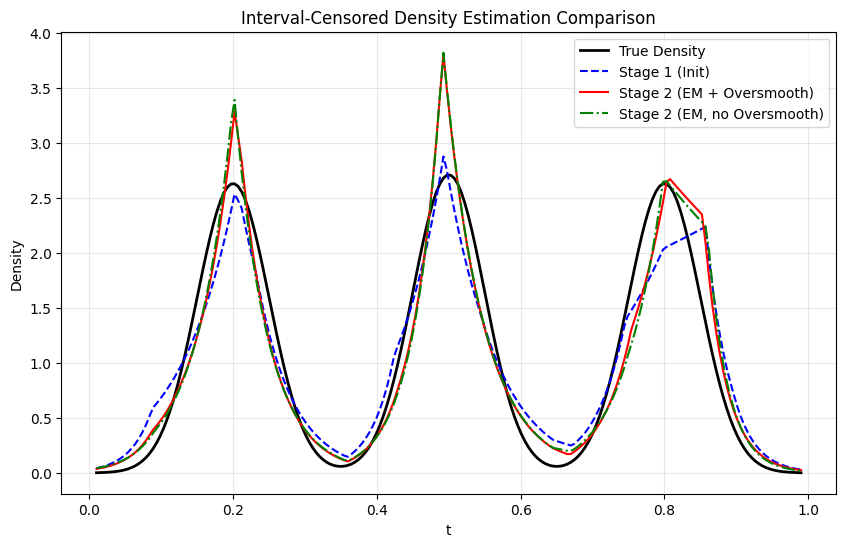

In [7]:
# Get densities from each estimator
grid = np.linspace(0.01, 0.99, 200)

init_density = init_result.estimator.get_density_at_points(grid)
em_oversmooth_density = em_result_oversmooth.estimator.get_density_at_points(grid)
em_no_oversmooth_density = em_result_no_oversmooth.estimator.get_density_at_points(grid)

# True density
# true_density = beta.pdf(grid, 2, 5)
true_density = sampler.compute_density(grid)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(grid, true_density, 'k-', lw=2, label='True Density')
plt.plot(grid, init_density, 'b--', lw=1.5, label='Stage 1 (Init)')
plt.plot(grid, em_oversmooth_density, 'r-', lw=1.5, label='Stage 2 (EM + Oversmooth)')
plt.plot(grid, em_no_oversmooth_density, 'g-.', lw=1.5, label='Stage 2 (EM, no Oversmooth)')
plt.xlabel('t')
plt.ylabel('Density')
plt.title('Interval-Censored Density Estimation Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# Compute log-likelihoods
init_ll = incomplete_loglik_interval(init_result.estimator, data)
em_oversmooth_ll = incomplete_loglik_interval(em_result_oversmooth.estimator, data)
em_no_oversmooth_ll = incomplete_loglik_interval(em_result_no_oversmooth.estimator, data)

print("Log-likelihood Comparison:")
print(f"  Stage 1 (Init):            {init_ll:.4f}")
print(f"  Stage 2 (EM + Oversmooth): {em_oversmooth_ll:.4f}")
print(f"  Stage 2 (EM, no Oversmooth): {em_no_oversmooth_ll:.4f}")

Log-likelihood Comparison:
  Stage 1 (Init):            -610.7911
  Stage 2 (EM + Oversmooth): -607.8787
  Stage 2 (EM, no Oversmooth): -608.3105
